# Image Classification – Deep Learning Project in Python with Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

D:\python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

print("Train shape:", train_X.shape)
print("Test shape:", test_X.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


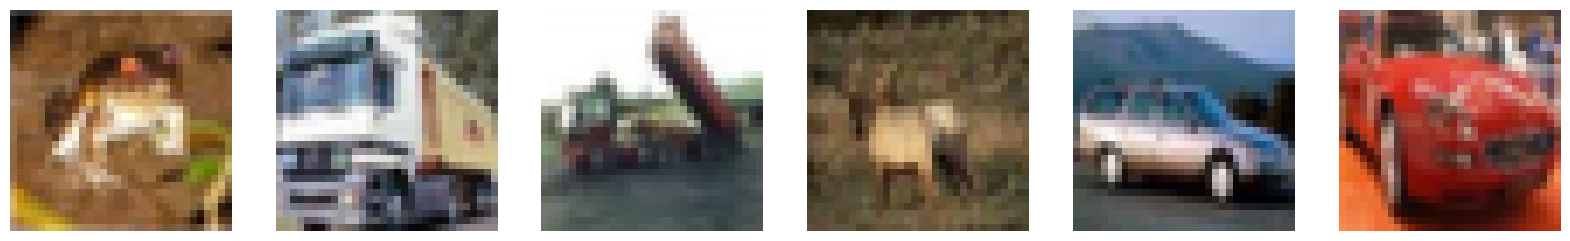

In [3]:
n = 6
plt.figure(figsize=(20,10))

for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(train_X[i])
    plt.axis('off')

plt.show()

In [4]:
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

In [5]:
train_Y = to_categorical(train_Y)
test_Y = to_categorical(test_Y)

num_classes = test_Y.shape[1]
print("Classes:", num_classes)

Classes: 10


In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3),
                 input_shape=(32,32,3),
                 padding='same',
                 activation='relu',
                 kernel_constraint=MaxNorm(3)))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3,3),
                 activation='relu',
                 padding='same',
                 kernel_constraint=MaxNorm(3)))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(512,
                activation='relu',
                kernel_constraint=MaxNorm(3)))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

D:\python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
sgd = SGD(
    learning_rate=0.01,
    momentum=0.9,
    decay=0.01/25,
    nesterov=False
)


D:\python313\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [8]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=sgd,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,210,090 (16.06 MB)

 Trainable params: 4,210,090 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_X, train_Y,
    validation_data=(test_X, test_Y),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 54ms/step - accuracy: 0.3576 - loss: 1.7797 - val_accuracy: 0.4390 - val_loss: 1.5084
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.4846 - loss: 1.4269 - val_accuracy: 0.5514 - val_loss: 1.2665
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.5545 - loss: 1.2467 - val_accuracy: 0.5799 - val_loss: 1.1759
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.6046 - loss: 1.1140 - val_accuracy: 0.6171 - val_loss: 1.0845
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.6475 - loss: 0.9940 - val_accuracy: 0.6432 - val_loss: 1.0183
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.6854 - loss: 0.8897 - val_accuracy: 0.6603 - val_loss: 0.9724
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.7119 - loss: 0.8107 - val_accuracy: 0.6628 - val_loss: 0.9824
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.74

In [10]:
_, acc = model.evaluate(test_X, test_Y)
print("Accuracy: %.2f%%" % (acc * 100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6716 - loss: 1.0232
Accuracy: 67.16%


In [11]:
model.save("model1_cifar_10epoch.keras")